In [2]:
#| include: false
import pandas as pd

# Display all columns
pd.set_option('display.max_columns', None)

# Ensure printing of all output for each cell
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Week 1

## Walkthrough 1.1: Getting Started

### Setting Up the Python Environment

If you haven't already installed Python, Jupyter, and the necessary packages, there are instructions on the course repo in the README to do so [here](https://github.com/ismayc/oreilly-statistical-modeling-and-inference-with-python/blob/main/README.md). 

If you aren't able to do this on your machine, you may want to check out [Google Colab](https://colab.research.google.com/). It's a free service that allows you to run Jupyter notebooks in the cloud.

In [2]:
# Importing libraries/modules and aliasing them as needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Load a dataset

In [3]:
# Load in the dataset
spotify_sample = pd.read_csv("spotify_sample.csv")

### Prepare data

In [5]:
# Select a single feature and target variable
X = spotify_sample[['acousticness']]
y = spotify_sample['energy']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2024)

### Train and use the model

Mean Squared Error: 0.022725844170862916
R^2 Score: 0.37411362686731486


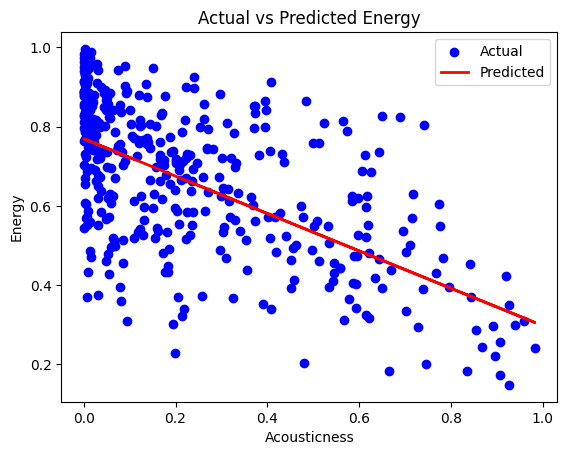

In [8]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

# Plotting the results
plt.scatter(X_test, y_test, color='blue', label='Actual');
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted');
plt.xlabel('Acousticness');
plt.ylabel('Energy');
plt.title('Actual vs Predicted Energy');
plt.legend();
plt.show();

### Check if assumptions of linear regression met with visual tools

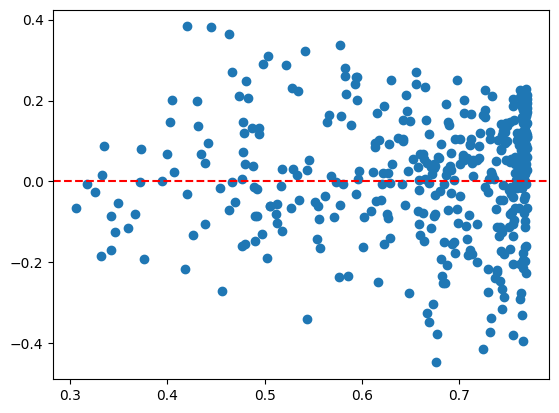

<Axes: xlabel='energy', ylabel='Count'>

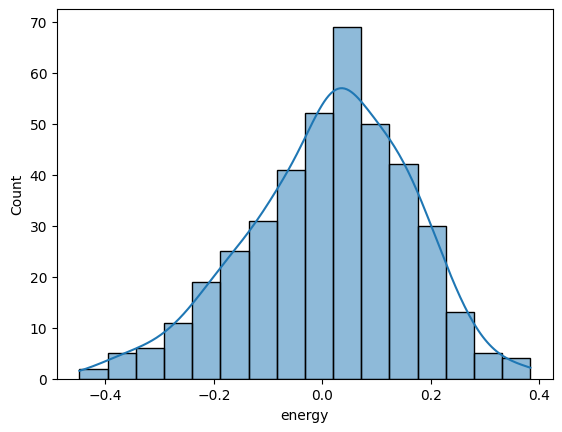

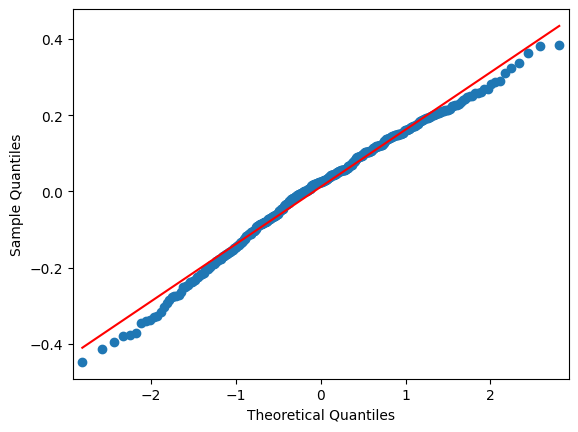

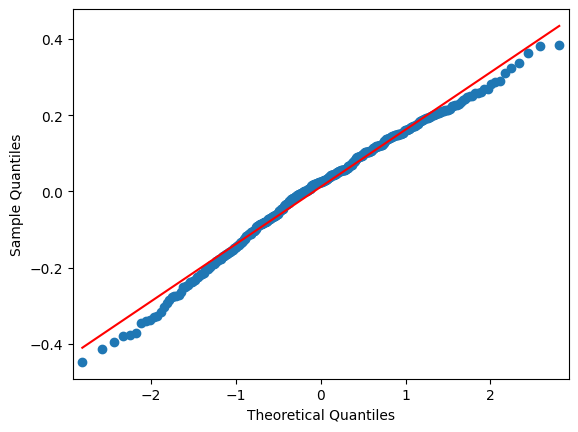

In [9]:
# Check for Homoscedasticity
residuals = y_test - y_pred
plt.scatter(y_pred, residuals);
plt.axhline(y=0, color='r', linestyle='--');
plt.show();

# Check for Normality of Residuals
sns.histplot(residuals, kde=True);
plt.show();

sm.qqplot(residuals, line='s');
plt.show()

## Exercise 1.1: Getting Started

### Setting Up the Python Environment

If you ran the `# Importing libraries and aliasing them` code above, you should 
be good to proceed here. If not, scroll up and run it.

### Load a dataset

In [ ]:
# Load in the dataset
imdb_movie_sample = pd.read_csv("imdb_movie_sample.csv")

### Prepare data

In [ ]:
# Select a single feature (votes) and target variable (rating)
X = imdb_movie_sample[['votes']]
y = imdb_movie_sample['rating']

# Split the data into training and testing (0.2 size) sets
# with seed of 2024


### Train and use the model

In [ ]:
# Create and train the model


# Make predictions


# Evaluate the model




# Plotting the results


### Check if assumptions of linear regression met with visual tools

In [ ]:
# Check for Homoscedasticity


# Check for Normality of Residuals


## Walkthrough 1.2: Correlation

### Correlation matrix

In [11]:
# Select only numeric columns
numeric_columns = spotify_sample.select_dtypes(include=[np.number])
numeric_columns

# Calculate Pearson correlation matrix
correlation_matrix = numeric_columns.corr()

# Display the correlation matrix
correlation_matrix

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,79,216880,0.639,0.526,0,-6.697,1,0.0256,0.245000,0.000024,0.2500,0.488,130.033,3
1,75,154486,0.881,0.592,2,-4.898,1,0.0324,0.619000,0.000013,0.0901,0.719,101.058,4
2,78,215672,0.647,0.585,6,-6.123,1,0.0512,0.003140,0.000000,0.1650,0.353,131.934,4
3,71,191506,0.491,0.942,7,-5.333,1,0.1320,0.156000,0.000000,0.3670,0.387,100.446,4
4,71,169174,0.655,0.569,1,-5.018,0,0.0349,0.716000,0.000007,0.1350,0.440,150.267,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019,83,208786,0.775,0.613,3,-4.586,0,0.0542,0.109000,0.000023,0.1340,0.797,100.066,4
2020,71,214720,0.637,0.864,8,-4.381,1,0.0468,0.484000,0.000000,0.2220,0.706,99.995,4
2021,73,115413,0.223,0.805,8,-8.969,1,0.0370,0.000179,0.814000,0.0849,0.250,168.165,4
2022,74,386493,0.540,0.584,7,-9.579,1,0.0254,0.010800,0.002960,0.2530,0.244,139.261,4


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,-0.082278,0.127532,0.010058,-0.027631,0.086216,-0.035483,0.044336,-0.066714,-0.056118,-0.008901,-0.020808,-0.009479,-0.006527
duration_ms,-0.082278,1.000000,-0.264755,0.008741,0.028283,-0.083199,0.047103,-0.125077,-0.047906,0.028249,-0.015372,-0.132867,-0.036287,-0.056409
danceability,0.127532,-0.264755,1.000000,0.079812,0.032541,0.222743,-0.128635,0.229544,-0.092686,-0.169265,-0.064824,0.418431,-0.129809,0.225751
energy,0.010058,0.008741,0.079812,1.000000,0.010671,0.722339,-0.082894,0.101975,-0.634235,-0.149437,0.155328,0.373744,0.149471,0.209150
key,-0.027631,0.028283,0.032541,0.010671,1.000000,0.009225,-0.120635,0.067418,0.003188,0.014540,-0.009253,0.007458,-0.011600,-0.024072
loudness,0.086216,-0.083199,0.222743,0.722339,0.009225,1.000000,-0.094020,0.094559,-0.476257,-0.340739,0.101894,0.245695,0.097394,0.230465
mode,-0.035483,0.047103,-0.128635,-0.082894,-0.120635,-0.094020,1.000000,-0.064826,0.106039,0.048699,0.007828,-0.010206,-0.018432,-0.056068
speechiness,0.044336,-0.125077,0.229544,0.101975,0.067418,0.094559,-0.064826,1.000000,-0.052236,-0.066858,0.027345,0.104855,0.132441,0.079879
acousticness,-0.066714,-0.047906,-0.092686,-0.634235,0.003188,-0.476257,0.106039,-0.052236,1.000000,0.125129,-0.090550,-0.203975,-0.129973,-0.188187
instrumentalness,-0.056118,0.028249,-0.169265,-0.149437,0.014540,-0.340739,0.048699,-0.066858,0.125129,1.000000,-0.042264,-0.155218,-0.035381,-0.131703


### Visualizing correlation matrix

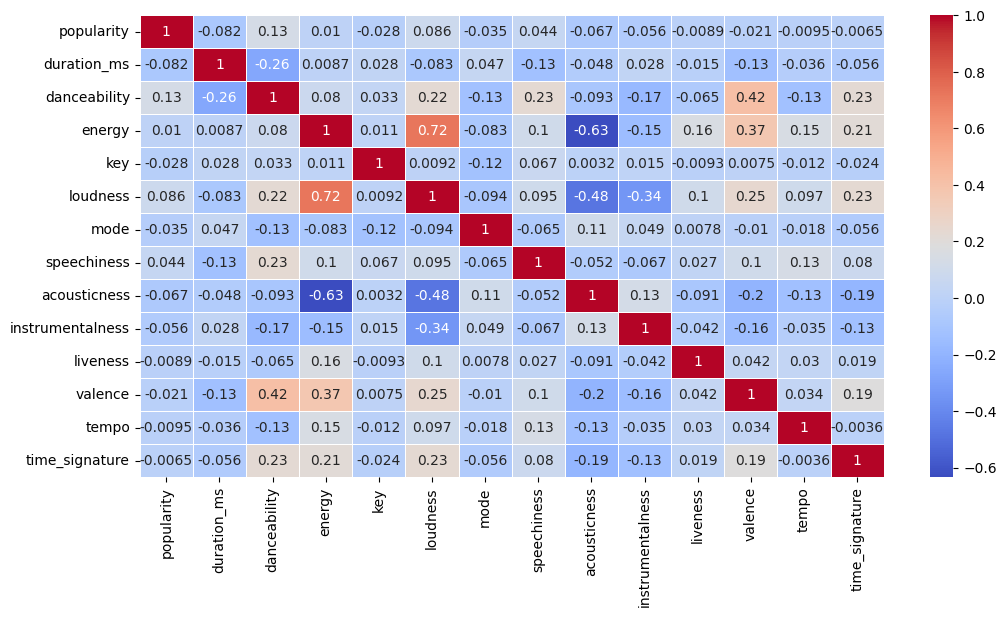

In [16]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 6));
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5);
plt.show();

### Visualizing relationships

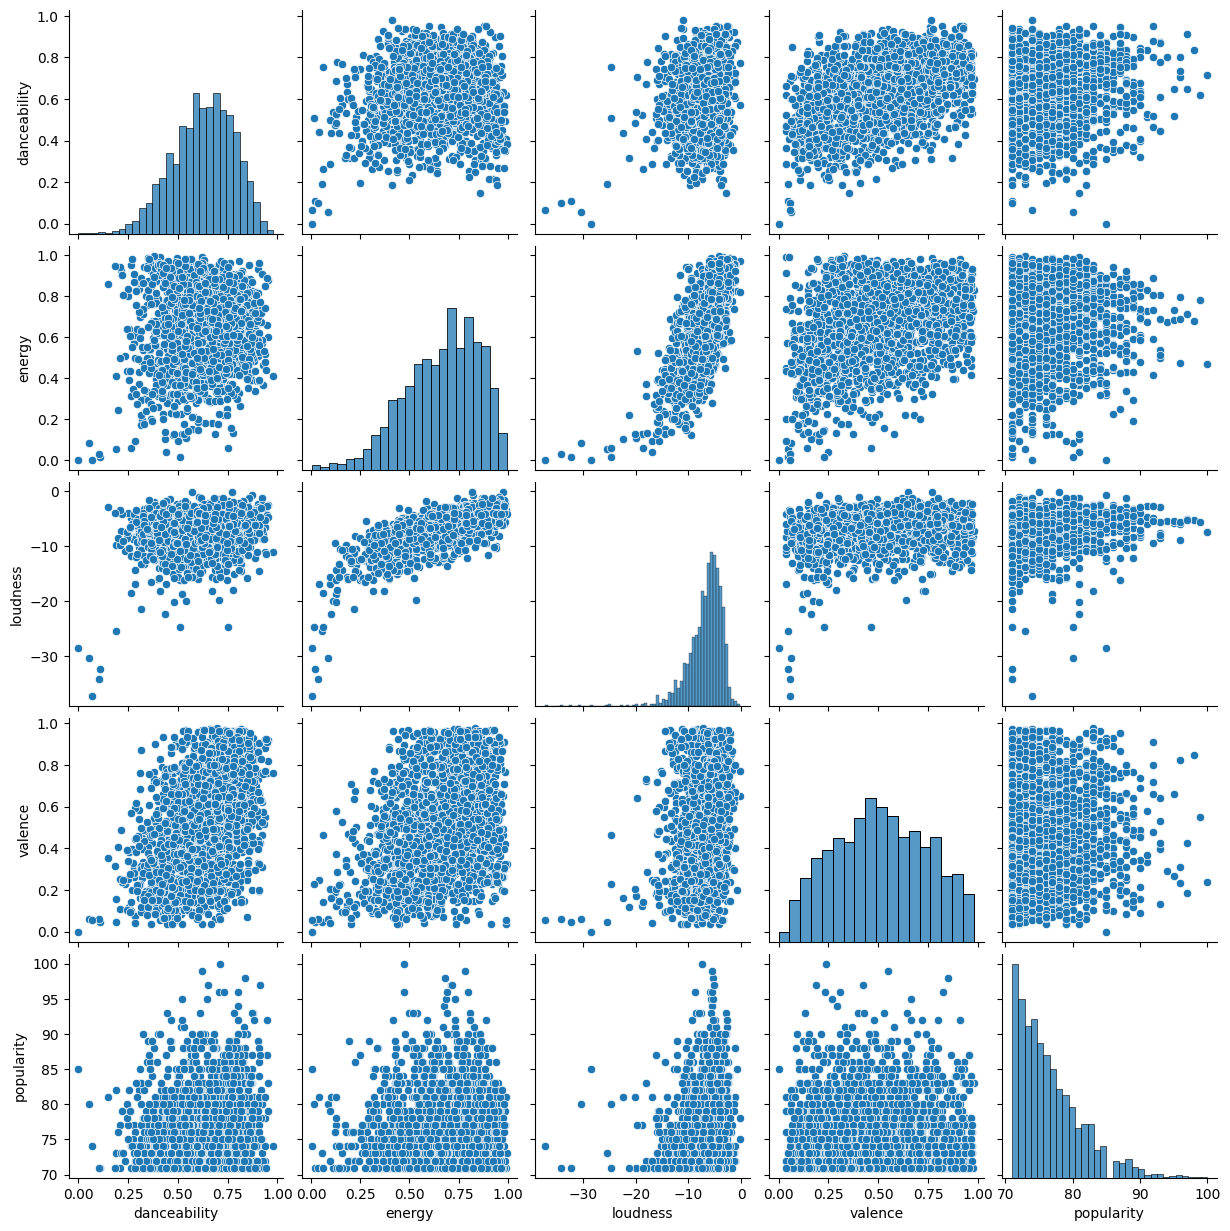

In [17]:
# Plot pairplot to visualize relationships
# between 'danceability', 'energy', 'loudness', 'valence', 'popularity'
sns.pairplot(numeric_columns[['danceability', 'energy', 'loudness', 'valence', 'popularity']]);
plt.show();

## Exercise 1.2: Correlation

### Correlation matrix

In [ ]:
# Select only numeric columns


# Calculate Pearson correlation matrix

# Display the correlation matrix


## Visualizing correlation matrix

In [ ]:
# Visualize the correlation matrix using a heatmap


### Visualizing relationships

In [ ]:
# Plot pairplot to visualize relationships of 
# runtime_in_minutes, rating, votes, and gross_in_dollars


## Walkthrough 1.3: Multiple Regression

In [18]:
# Prepare the data for multiple regression
X = spotify_sample[['danceability', 'energy', 'loudness']]
y = spotify_sample['popularity']

# Add a constant to the predictor variable set
X = sm.add_constant(X)

# Fit the multiple regression model
model = sm.OLS(y, X).fit()

# Print the model summary
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             popularity   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     16.35
Date:                Mon, 05 Aug 2024   Prob (F-statistic):           1.70e-10
Time:                        12:38:18   Log-Likelihood:                -6062.2
No. Observations:                2024   AIC:                         1.213e+04
Df Residuals:                    2020   BIC:                         1.215e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           77.1758      1.009     76.516      0.000      75.198      79.154
danceability     3.4069      0.729      4.675      0.000       1.978       4.836
energy          -2.3508      0.826     -2.848      0.004      -3.970      -0.732
loudness         0.1914      0.049      3.922      0.000       0.096       0.287
==============================================================================
Omnibus:                      360.167   Durbin-Watson:                   1.977
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              608.950
Skew:                           1.152   Prob(JB):                    5.86e-133
Kurtosis:                       4.383   Cond. No.                         91.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Exercise 1.3: Multiple Regression

In [ ]:
# Prepare the data for multiple regression choosing runtime_in_minutes, votes, 
# and gross_in_dollars as predictors and rating as the target variable


# Add a constant to the predictor variable set


# Fit the multiple regression model


# Print the model summary


## Walkthrough 1.4: Logistic Regression

In [19]:
# Define the predictors and response
X = spotify_sample[['danceability', 'energy', 'loudness']]
y = (spotify_sample['popularity'] > 75).astype(int)

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
model = sm.Logit(y, X).fit()

# Print the summary
model.summary()

Optimization terminated successfully.
         Current function value: 0.684671
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             popularity   No. Observations:                 2024
Model:                          Logit   Df Residuals:                     2020
Method:                           MLE   Df Model:                            3
Date:                Mon, 05 Aug 2024   Pseudo R-squ.:                 0.01133
Time:                        13:36:52   Log-Likelihood:                -1385.8
converged:                       True   LL-Null:                       -1401.6
Covariance Type:            nonrobust   LLR p-value:                 5.908e-07
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0700      0.425      0.165      0.869      -0.763       0.903
danceability     1.2074      0.306      3.946      0.000       0.608       1.807
energy          -0.7250      0.348     -2.083      0.037      -1.407      -0.043
loudness         0.0626      0.021      2.925      0.003       0.021       0.104
================================================================================
"""

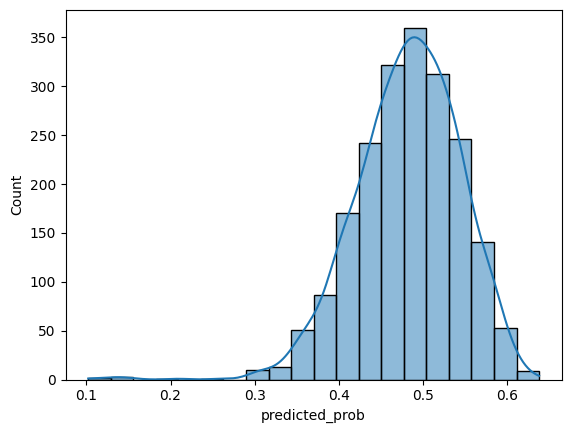

In [21]:
# Predict probabilities
spotify_sample['predicted_prob'] = model.predict(X)

# Plot the predicted probabilities
sns.histplot(spotify_sample['predicted_prob'], bins=20, kde=True)
plt.show();

## Exercise 1.4: Logistic Regression

In [ ]:
# Define the predictors (runtime_in_minutes & votes) and response (rating > 7)


# Add a constant to the model (intercept)


# Fit the logistic regression model


# Print the summary


# Predict probabilities


# Plot the predicted probabilities


## Walkthrough 1.5: ANOVA

### One-way ANOVA

In [22]:
from statsmodels.formula.api import ols

# Choose some genres to compare
genres = ['pop', 'rock', 'hip-hop', 'jazz']

# Subset the data to focus only on these genres
spotify_sample_subset = spotify_sample[spotify_sample['track_genre'].isin(genres)]

# Perform one-way ANOVA analyzing energy across different genres
model = ols('energy ~ C(track_genre)', data=spotify_sample_subset).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(track_genre),0.693407,3.0,9.11268,0.000011
Residual,5.275748,208.0,NaN,NaN


### Boxplot across groups

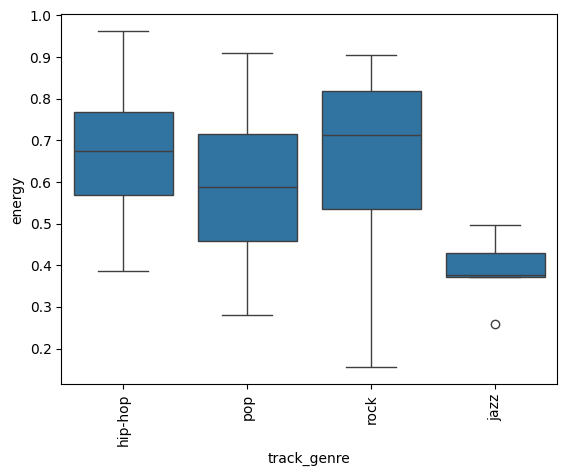

In [25]:
# Boxplot for visualization
sns.boxplot(x='track_genre', y='energy', data=spotify_sample_subset)

# Adjust layout to prevent labels from being cut off
plt.xticks(rotation=90)

# Show the plot
plt.show();

### Two-way ANOVA

In [26]:
# Perform two-way ANOVA analyzing energy across genres and explicit content
model = ols('energy ~ C(track_genre) * C(explicit)', data = spotify_sample_subset).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

/Users/chester/.virtualenvs/my_new_env/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/Users/chester/.virtualenvs/my_new_env/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(track_genre),0.432899,3.0,5.634451,0.004148
C(explicit),0.022365,1.0,0.873272,0.351151
C(track_genre):C(explicit),0.036156,3.0,0.470592,0.625305
Residual,5.250099,205.0,NaN,NaN


### Boxplot across groups with color added

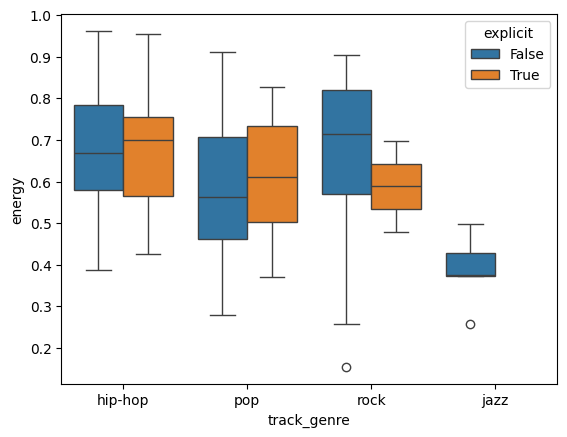

In [27]:
# Boxplot for visualization
sns.boxplot(x='track_genre', y='energy', hue='explicit', data=spotify_sample_subset);

## Exercise 1.5: ANOVA

### One-way ANOVA

In [ ]:
# Choose some genres to compare ('Action', 'Crime', 'Horror', 'Romance')


# Subset the data to focus only on these genres

# Perform one-way ANOVA analyzing rating across different genres


### Boxplot across groups

In [ ]:
# Boxplot for visualization


### Two-way ANOVA

In [ ]:
# Perform two-way ANOVA analyzing rating across genres and decades


### Boxplot across groups with color added

In [ ]:
# Some customization here to get the decades to appear in the appropriate order

# Define the ordered categories
decades = ['1940s', '1950s', '1960s', '1970s', '1980s', '1990s', '2000s', '2010s', '2020s']

# Convert 'decade' column to a categorical type with ordered categories
imdb_movie_sample_subset['decade'] = pd.Categorical(imdb_movie_sample_subset['decade'], categories=decades, ordered=True)

# Boxplot for visualization


## Walkthrough 2.1: Kruskal-Wallis and Mann-Whitney U Tests

### Kruskal-Wallis

In [4]:
import scipy.stats as stats

# Perform Kruskal-Wallis Test on 'danceability' grouped by 'track_genre'
grouped_data = [group["danceability"].values for name, group in spotify_sample.groupby("track_genre")]
stat, p_value = stats.kruskal(*grouped_data)
print(f"Kruskal-Wallis Test Statistic: {stat}")
print(f"P-value: {p_value}")

Kruskal-Wallis Test Statistic: 716.1550864769308
P-value: 8.079896027452026e-106


### Mann-Whitney U

In [5]:
# Perform Mann-Whitney U Test on 'energy' for pop versus rock
group1 = spotify_sample[spotify_sample["track_genre"] == "pop"]["energy"]
group2 = spotify_sample[spotify_sample["track_genre"] == "rock"]["energy"]
stat, p_value = stats.mannwhitneyu(group1, group2)
print(f"Man -Whitney U Test Statistic: {stat}")
print(f"P-value: {p_value}")

Man -Whitney U Test Statistic: 1331.5
P-value: 0.006209251182150305


## Exercise 2.1: Kruskal-Wallis and Mann-Whitney U Tests

### Kruskal-Wallis

In [ ]:
# Perform Kruskal-Wallis Test on 'rating' grouped by 'decade'


### Mann-Whitney U

In [ ]:
# Perform Mann-Whitney U Test on 'gross_in_dollars' for 1990s versus 2000s


## Walkthrough 2.2: Correlation and Regression Non-parametrics

### Spearman's Rank Correlation

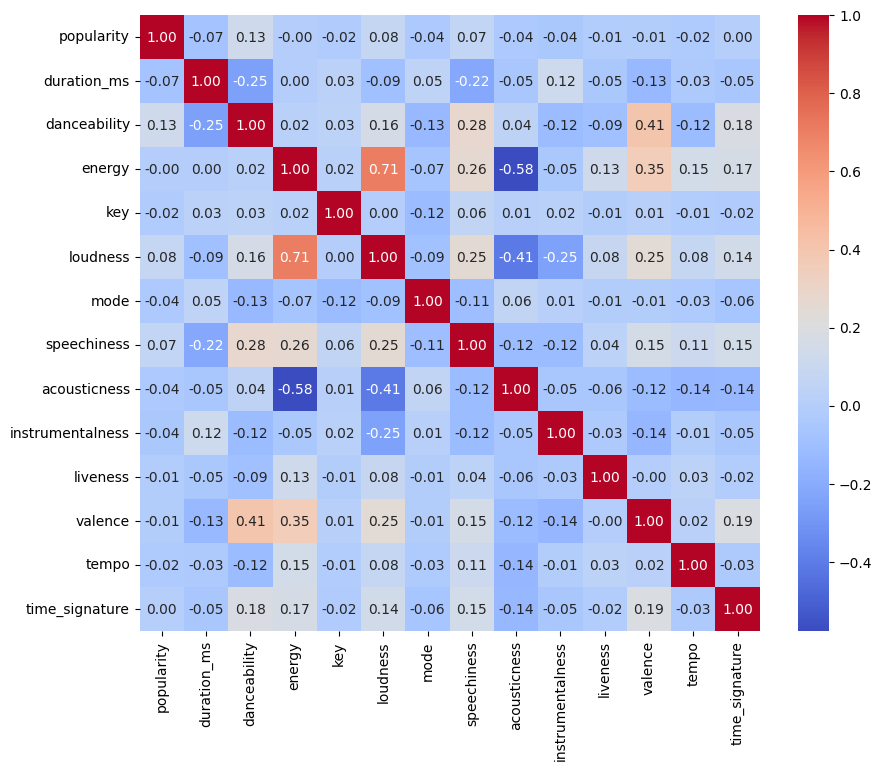

In [8]:
from scipy.stats import spearmanr, kendalltau
from sklearn.linear_model import TheilSenRegressor

# Filter numeric columns
numeric_columns = spotify_sample.select_dtypes(include=[np.number])

# Calculate Spearman's rank correlation matrix
spearman_corr = numeric_columns.corr(method='spearman')
spearman_corr

# Heatmap for Spearman's rank correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show();

### Kendall's Tau Correlation

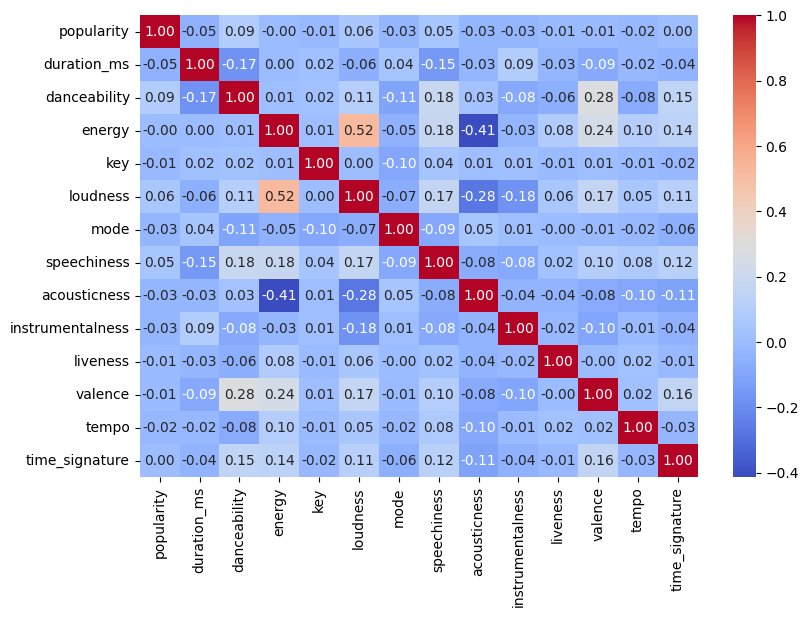

In [10]:
# Calculate Kendall's tau correlation matrix
kendall_corr = numeric_columns.corr(method='kendall')

# Heatmap for Kendall's tau correlation matrix
plt.figure(figsize=(9, 6))
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show();

### Theil-Sen Robust Regression

In [12]:
# Theil-Sen robust regression for 'danceability' and 'energy' predicting 'popularity'
X = numeric_columns[['danceability', 'energy']]
y = numeric_columns['popularity']
theil_sen = TheilSenRegressor()
theil_sen.fit(X, y)
print("Intercept:", theil_sen.intercept_)
print("Coefficients:", theil_sen.coef_)

Intercept: 73.82177237536071
Coefficients: [ 3.45263138 -0.98454958]


## Exercise 2.2: Correlation and Regression Non-parametrics

### Spearman's Rank Correlation

In [ ]:
# Filter numeric columns

# Calculate Spearman's rank correlation matrix


# Heatmap for Spearman's rank correlation matrix


### Kendall's Tau Correlation

In [ ]:
# Calculate Kendall's tau correlation matrix


# Heatmap for Kendall's tau correlation matrix


### Theil-Sen Robust Regression

In [ ]:
# Theil-Sen robust regression for 'votes' and 'runtime_in_minutes' predicting 'rating'


## Walkthrough 2.3: Bootstrapping

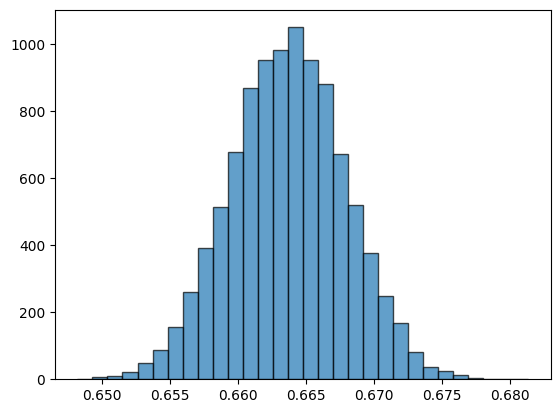

In [21]:
# Function to perform bootstrapping
def bootstrap(data, n_bootstrap_samples=1000):
    bootstrap_samples = []
    np.random.seed(2024)
    for _ in range(n_bootstrap_samples):
        resample = data.sample(frac=1, replace=True)
        bootstrap_samples.append(resample.mean())
    return bootstrap_samples

# Perform bootstrapping on the 'energy' column
bootstrap_means = bootstrap(spotify_sample['energy'],
                           n_bootstrap_samples=10000)

# Plot the distribution of bootstrap means
plt.hist(bootstrap_means, bins=30, alpha=0.7, edgecolor='k')
plt.show();

## Exercise 2.3: Bootstrapping

In [ ]:
# Perform bootstrapping on the 'runtime_in_minutes' column
# using the bootstrap function defined above

# Plot the distribution of bootstrap means


## Walkthrough 2.4: Confidence Intervals

95% Confidence Interval for Mean Energy: [0.6551935733695652, 0.671423394762846]


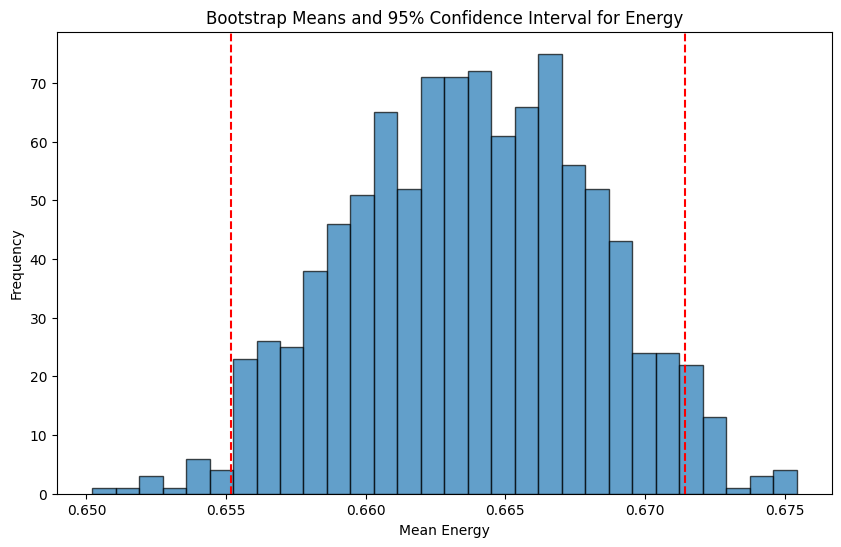

In [23]:
# Function to calculate bootstrap confidence intervals
def bootstrap_confidence_interval(data, n_bootstrap_samples=1000, confidence_level=0.95):
    bootstrap_samples = []
    np.random.seed(2024)
    for _ in range(n_bootstrap_samples):
        resample = data.sample(frac=1, replace=True)
        bootstrap_samples.append(resample.mean())
    lower_bound = np.percentile(bootstrap_samples, (1 - confidence_level) / 2 * 100)  
    upper_bound = np.percentile(bootstrap_samples, (1 + confidence_level) / 2 * 100)  
    return lower_bound, upper_bound

# Calculate confidence intervals for the 'energy' column
lower, upper = bootstrap_confidence_interval(spotify_sample['energy'])
print(f"95% Confidence Interval for Mean Energy: [{lower}, {upper}]")

# Plot the distribution of bootstrap means and confidence interval
bootstrap_means = [spotify_sample['energy'].sample(frac=1, replace=True).mean() for _ in range(1000)]
plt.figure(figsize=(10, 6))
plt.hist(bootstrap_means, bins=30, edgecolor='k', alpha=0.7)
plt.axvline(lower, color='r', linestyle='--')
plt.axvline(upper, color='r', linestyle='--')
plt.title('Bootstrap Means and 95% Confidence Interval for Energy')
plt.xlabel('Mean Energy')
plt.ylabel('Frequency')
plt.show();

## Exercise 2.4: Confidence Intervals

In [ ]:
# Calculate confidence intervals for the 'rating' column using the
# bootstrap_confidence_interval function defined above

# Plot the distribution of bootstrap means and confidence interval


## Walkthrough 2.5: Real-World Scenarios for Bootstrapping

**Music Industry Analytics**

*Objective*: Analyzing song popularity and estimating population mean popularity.

*Scenario*: You are a data scientist for a movie production company. Your role is to analyze movie ratings and predict the average rating of movies produced. By using bootstrapping techniques, you aim to estimate the mean movie rating and its variability to understand the unknown population mean.

*Bootstrapping Applications*:

- *Estimating Average Popularity*: Use bootstrapping to calculate the mean and confidence intervals of the popularity scores.
- *Assessing Variability*: Determine the variability in the means of song popularity.

In [ ]:
# Calculate bootstrap statistics for the 'popularity' column

# Function to calculate bootstrap statistics


# Plot the distribution of bootstrap means


## Exercise 2.5: Real-World Scenarios for Bootstrapping

**Film Industry Insights**

*Objective*: Evaluating movie gross revenue and estimating population mean gross revenue.

*Scenario*: You are a data scientist for a movie production company. Your role is to analyze movie gross revenue and predict the average gross revenue of movies produced. By using bootstrapping techniques, you aim to estimate the mean gross revenue and its variability to understand the unknown population mean.

*Bootstrapping Applications*:

- *Estimating Average Gross Revenue*: Use bootstrapping to calculate the mean and confidence intervals of movie gross revenue.
- *Assessing Variability*: Determine the variability in the means of movie gross revenue.

In [ ]:
# Calculate bootstrap statistics for the 'gross_in_dollars' column
# using the function called bootstrap_statistics defined above


# Plot the distribution of bootstrap means
